In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stat

## Función para el muestreo

In [ ]:
def muestreoporestrato(df, condicion):
    return df.query(condicion).copy()

#Posible uso:
#df = pd.read_csv('datos.csv')
#condicion = "Variable == 'DViento' & Unidades == 'deg' & `Tiempo de exposición (horas)` == 24"
#estrato = muestreoporestrato(df, condicion)

## Función para resumen inferencial

In [ ]:
import numpy as np
from scipy import stats

def resumen_inferencial(muestra, alpha=0.05):
    """
    Recibe una muestra (array) y devuelve un diccionario con:
    - Estadísticas descriptivas
    - IC para la media (t de Student)
    - IC para la varianza (chi-cuadrado)
    """
    n        = len(muestra)
    media    = np.mean(muestra)
    varianza = np.var(muestra, ddof=1)
    desv_std = np.std(muestra, ddof=1) #desviación estándar muestral 
    gl       = n - 1

    # --- IC para la media (t-Student bilateral) ---
    t_critico   = stats.t.ppf(1 - alpha/2, df=gl)
    margen      = t_critico * (desv_std / np.sqrt(n))
    IC_med_inf  = media - margen
    IC_med_sup  = media + margen

    # --- IC para la varianza (chi-cuadrado bilateral) ---
    chi2_izq    = stats.chi2.ppf(alpha/2,     df=gl)
    chi2_der    = stats.chi2.ppf(1 - alpha/2, df=gl)
    IC_var_inf  = (gl * varianza) / chi2_der
    IC_var_sup  = (gl * varianza) / chi2_izq

    # --- Imprimir resumen ---
    sep = "=" * 45
    print(f"\n  ESTADÍSTICAS DE LA MUESTRA")
    print(sep)
    print(f"  n                    : {n}")
    print(f"  Media muestral (x̄)  : {media:.4f}")
    print(f"  Varianza muestral(S²): {varianza:.4f}")
    print(f"  Desviación std  (S)  : {desv_std:.4f}")

    print(f"\n  INTERVALO DE CONFIANZA PARA LA MEDIA")
    print(f"  t crítico (gl={gl}, α/2): {t_critico:.4f}")
    print(f"  Margen de error       : ± {margen:.4f}")
    print(f"  IC {int((1-alpha)*100)}%: [ {IC_med_inf:.4f} , {IC_med_sup:.4f} ]")

    print(f"\n  INTERVALO DE CONFIANZA PARA LA VARIANZA")
    print(f"  χ² izquierdo (α/2)   : {chi2_izq:.4f}")
    print(f"  χ² derecho   (1-α/2) : {chi2_der:.4f}")
    print(f"  IC {int((1-alpha)*100)}%: [ {IC_var_inf:.4f} , {IC_var_sup:.4f} ]")

    #  GRÁFICA 1: IC de la media en recta numérica
    fig, ax = plt.subplots(figsize=(10, 2.8))          #primero el ax
    media_ref = 7.1                                     #luego la ref

    padding = margen * 2
    ax.plot([IC_med_inf, IC_med_sup], [0, 0], 'b-', linewidth=5, solid_capstyle='round')
    ax.plot([IC_med_inf - padding, IC_med_inf], [0, 0], color='gray', linewidth=1.2, linestyle='--', alpha=0.4)
    ax.plot([IC_med_sup, IC_med_sup + padding], [0, 0], color='gray', linewidth=1.2, linestyle='--', alpha=0.4)
    ax.plot(IC_med_inf, 0, 'b|', markersize=22, markeredgewidth=3)
    ax.plot(IC_med_sup, 0, 'b|', markersize=22, markeredgewidth=3)
    ax.plot(media, 0, 'o', color='#27ae60', markersize=13, zorder=5,
            markeredgecolor='white', markeredgewidth=2)
    ax.axvline(media_ref, color='red', linestyle='--', linewidth=1.8,
            label=f'μ ref = {media_ref}')
    ax.annotate(f'LI = {IC_med_inf:.4f}', xy=(IC_med_inf, 0),
                xytext=(IC_med_inf, 0.032), ha='center', fontsize=9,
                color='#2980b9', fontweight='bold')
    ax.annotate(f'x̄ = {media:.4f}', xy=(media, 0),
                xytext=(media, -0.038), ha='center', fontsize=9,
                color='#27ae60', fontweight='bold')
    ax.annotate(f'LS = {IC_med_sup:.4f}', xy=(IC_med_sup, 0),
                xytext=(IC_med_sup, 0.032), ha='center', fontsize=9,
                color='#2980b9', fontweight='bold')
    ax.annotate(f'μ ref = {media_ref}', xy=(media_ref, 0),
                xytext=(media_ref, -0.055), ha='center', fontsize=8,
                color='red', fontweight='bold')
    ax.set_xlim(IC_med_inf - padding, IC_med_sup + padding)
    ax.set_ylim(-0.07, 0.07)
    ax.set_yticks([])
    ax.set_title(f'IC {int((1-alpha)*100)}% para la Media — t-Student bilateral',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Valores de la variable', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # GRÁFICA 2
    x_chi = np.linspace(max(0, gl * 0.4), gl * 1.8, 1000)
    y_chi = stats.chi2.pdf(x_chi, df=gl)

    fig, ax = plt.subplots(figsize=(10, 4))             #primero el ax
    ax.plot(x_chi, y_chi, color='#2980b9', linewidth=2, label=f'χ² (gl={gl})')
    x_rec_izq = np.linspace(max(0, gl * 0.4), chi2_izq, 300)
    ax.fill_between(x_rec_izq, stats.chi2.pdf(x_rec_izq, df=gl),
                    alpha=0.4, color='#e74c3c', label='Zona de rechazo (α/2)')
    x_rec_der = np.linspace(chi2_der, gl * 1.8, 300)
    ax.fill_between(x_rec_der, stats.chi2.pdf(x_rec_der, df=gl),
                    alpha=0.4, color='#e74c3c')
    x_ic = np.linspace(chi2_izq, chi2_der, 500)
    ax.fill_between(x_ic, stats.chi2.pdf(x_ic, df=gl),
                    alpha=0.18, color='#2980b9', label=f'IC {int((1-alpha)*100)}% varianza')
    ax.axvline(chi2_izq, color='#e74c3c', linestyle='--', linewidth=1.8)
    ax.axvline(chi2_der, color='#e74c3c', linestyle='--', linewidth=1.8)
    ax.axvline(gl, color='#27ae60', linestyle='-', linewidth=2,
            label=f'S² observada → (n-1) = {gl}')
    y_peak  = stats.chi2.pdf(gl-1, df=gl)             #después del ax
    var_ref  = 1.69
    stat_ref = (gl * var_ref) / varianza                 #después del ax
    ax.axvline(stat_ref, color='purple', linestyle='--', linewidth=1.8,
            label=f'σ²ref Stanton = {var_ref} → χ²= {stat_ref:.2f}')
    ax.text(chi2_izq, y_peak * 0.55, f' χ²izq\n {chi2_izq:.2f}',
            ha='left', fontsize=8, color='#e74c3c', fontweight='bold')
    ax.text(chi2_der, y_peak * 0.55, f' χ²der\n {chi2_der:.2f}',
            ha='left', fontsize=8, color='#e74c3c', fontweight='bold')
    ax.text(gl, y_peak * 0.85, f'  gl={gl}',
            ha='left', fontsize=8, color='#27ae60', fontweight='bold')
    ax.text(stat_ref, y_peak * 0.65, f'  σ²ref\n  {stat_ref:.2f}',
            ha='left', fontsize=8, color='purple', fontweight='bold')
    ax.set_title(f'Distribución χ² — IC {int((1-alpha)*100)}% para la Varianza',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Valores χ²', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Retornar todo en un diccionario ---
    return {
        "n": n, "media": media, "varianza": varianza, "desv_std": desv_std,
        "IC_media": (IC_med_inf, IC_med_sup),
        "IC_varianza": (IC_var_inf, IC_var_sup)
    }


## Estadistica muestral z

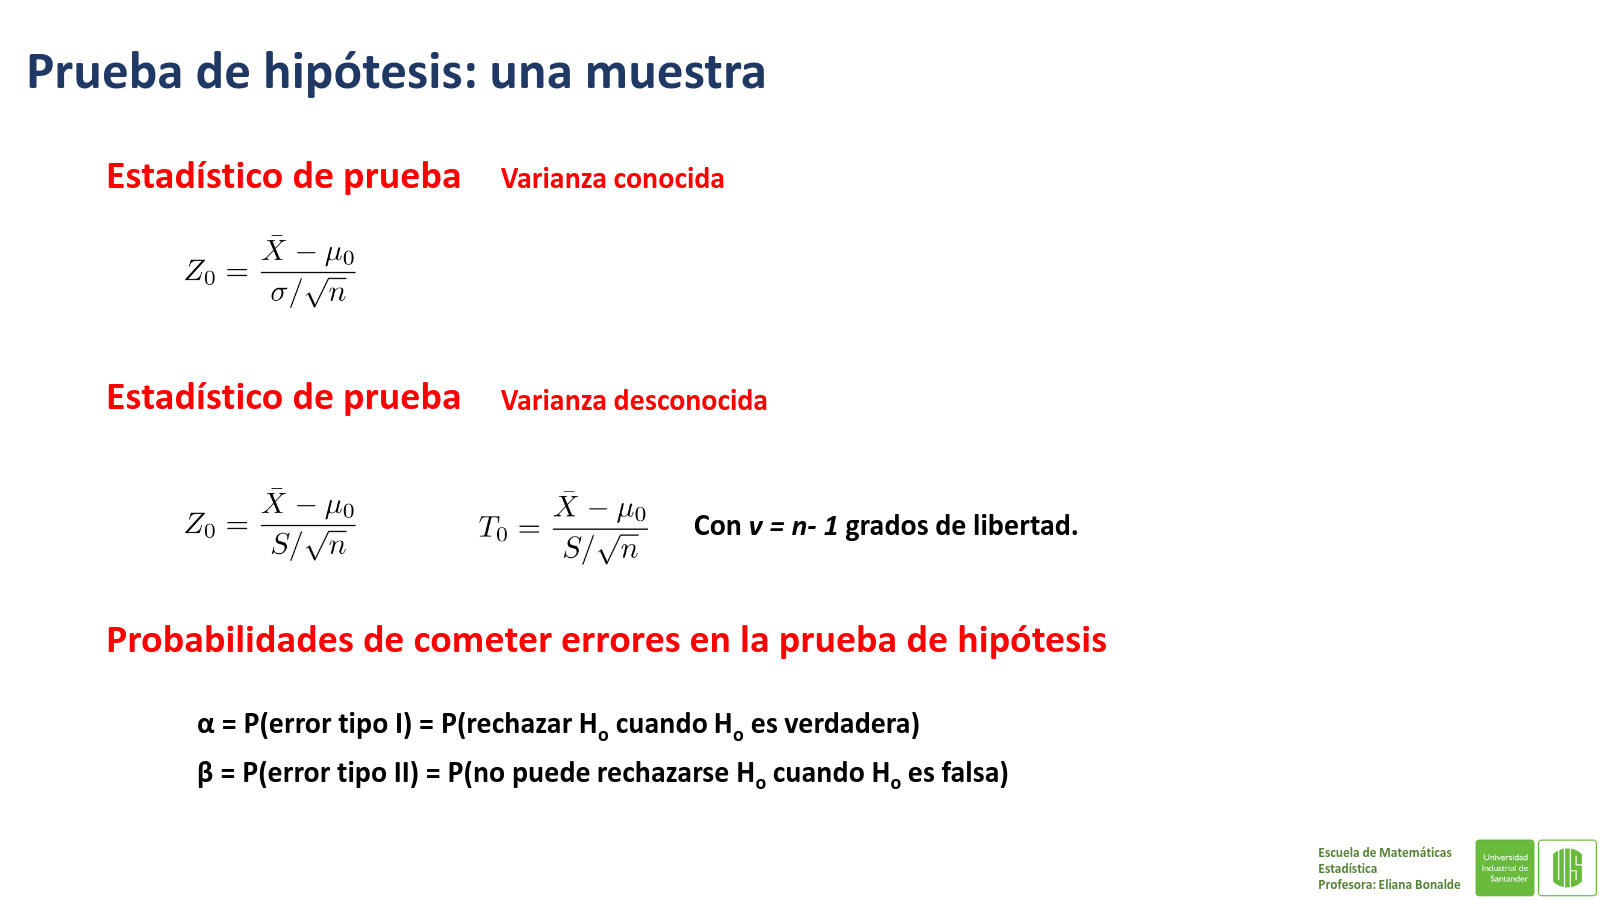

In [ ]:
def resolver_estadistica_muestral(mu, sigma, n, x_lim=None, tipo='probabilidad'):
    """
    Resuelve problemas de distribución muestral de la media.
    
    Args:
        mu (float): Media poblacional.
        sigma (float): Desviación estándar poblacional.
        n (int): Tamaño de la muestra.
        x_lim (float/tuple): Valor o intervalo de la media muestral (X barra).
        tipo (str): 'probabilidad', 'z_score' o 'intervalo'.
    """
    # 1. Calcular el Error Estándar (Desviación de la distribución muestral)
    sigma_x = sigma / np.sqrt(n)
    if n < 30:
        print("⚠️  AVISO: n < 30. Los resultados de probabilidad solo son válidos")
        print("   si el enunciado confirma que la población original es NORMAL.")
        print("   (Teorema del Límite Central no garantizado).")

    print(f"--- Resultados para n={n} ---")
    print(f"Media muestral (mu_x): {mu}")
    print(f"Desviación estándar para (X_barra): {sigma_x:.4f}")

    if tipo == 'probabilidad' and x_lim is not None:
        if isinstance(x_lim, (int, float)):
            prob_acumulada = stat.norm.cdf(x_lim, loc=mu, scale=sigma_x)
            
            # Por defecto calcula menor que, pero lo dejamos claro en el print
            print(f"P(X_barra <= {x_lim}) = {prob_acumulada:.4f}")
            print(f"P(X_barra > {x_lim}) = {1 - prob_acumulada:.4f} (Complemento/Exceder)")
    
            return prob_acumulada # Retorna la acumulada por defecto
        
        # Si es un intervalo (ej: para el ejercicio 47a: x_lim=(11.99, 12.01))
        elif isinstance(x_lim, tuple):
            inf, sup = x_lim
            prob_sup = stat.norm.cdf(sup, loc=mu, scale=sigma_x)
            prob_inf = stat.norm.cdf(inf, loc=mu, scale=sigma_x)
            total_prob = prob_sup - prob_inf
            print(f"P({inf} <= X_barra <= {sup}) = {total_prob:.4f}")
            return total_prob

## Funcion ley de los grandes números y del limite central

In [ ]:
def TLCyLGN(cs_estrato,variable,n,num_muestras):
    N = cs_estrato.shape[0]
    muestra = cs_estrato[variable].dropna().sample(n=n, random_state=42)
    tamaños = list(range(1, N, 10))
    medias_muestrales = []
    media_poblacional = cs_estrato[variable].dropna().mean()
    medias = []
    #LGN
    for n in tamaños:
        muestra = cs_estrato[variable].dropna().sample(n=n, random_state=42)
        medias_muestrales.append(muestra.mean())
    plt.figure(figsize=(8,5))
    plt.plot(tamaños, medias_muestrales, 'bo-', linewidth=2, markersize=8)
    plt.axhline(media_poblacional, color='red', linestyle='--', label=f'Media real: {media_poblacional:.2f}')
    plt.xlabel('Tamaño muestra (n)'); plt.ylabel('Media muestral'); plt.legend(); plt.grid(True); plt.title('Ley de los Grandes Números')
    plt.show()
    
    # ── DISTRIBUCIÓN ORIGINAL (antes del TLC) 
    datos_originales = cs_estrato[variable].dropna()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(datos_originales, bins=30, color='#2980b9', edgecolor='white',
            linewidth=0.5, alpha=0.75, density=True, label='Distribución original')
    ax.axvline(media_poblacional, color='red', linestyle='--', linewidth=2,
            label=f'Media poblacional: {media_poblacional:.2f}')
    ax.axvline(datos_originales.median(), color='orange', linestyle=':', linewidth=2,
            label=f'Mediana: {datos_originales.median():.2f}')
    ax.set_title(f'Distribución Original — {variable}', fontsize=11, fontweight='bold')
    ax.set_xlabel(variable, fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    #TLC
    for i in range(num_muestras):
        muestra = cs_estrato[variable].dropna().sample(n=n, replace=False)
        medias.append(muestra.mean())
    plt.hist(medias, bins=30)
    plt.xlabel("Media muestral")
    plt.ylabel("Frecuencia")
    plt.title("Teorema del Límite Central")
    plt.show()

#Posible uso:
#TLCyLGN(estrato, 'Valor', 30, 1000)

## Calcular la varianza empirica de una cantida de muestras




In [ ]:
def varemp (mu,sigma,n,m): #mu: media poblacional, sigma: desviación estándar poblacional, n: tamaño de la muestra, m: número de muestras
    np.random.seed(42) 
    medias=[]
    medianas=[]
    for i in range(m):
        muestra=np.random.normal(mu,sigma,n)
        medias.append(np.mean(muestra))
        medianas.append(np.median(muestra))
        
    medias=np.array(medias)
    medianas=np.array(medianas)
    var_media=np.var(medias,ddof=1)
    var_mediana=np.var(medianas,ddof=1) ##ddof=1 para varianza muestral
    return var_media,var_mediana

#Posible uso:
#var_media,var_mediana = varemp(0,1,30,1000)

## Prueba de hipotesis z

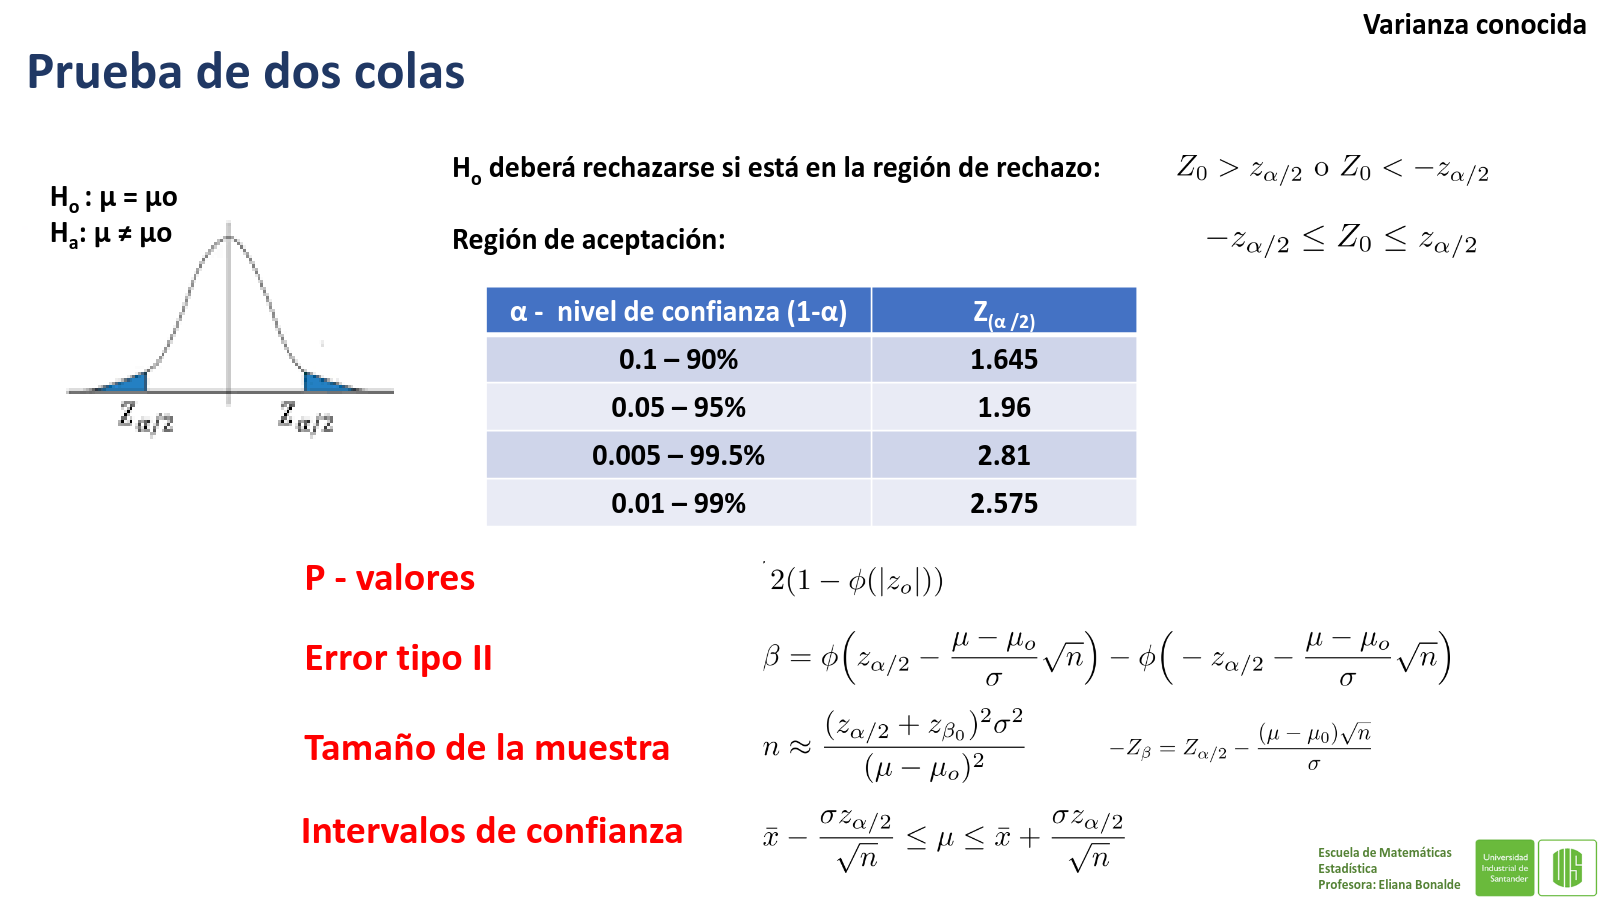 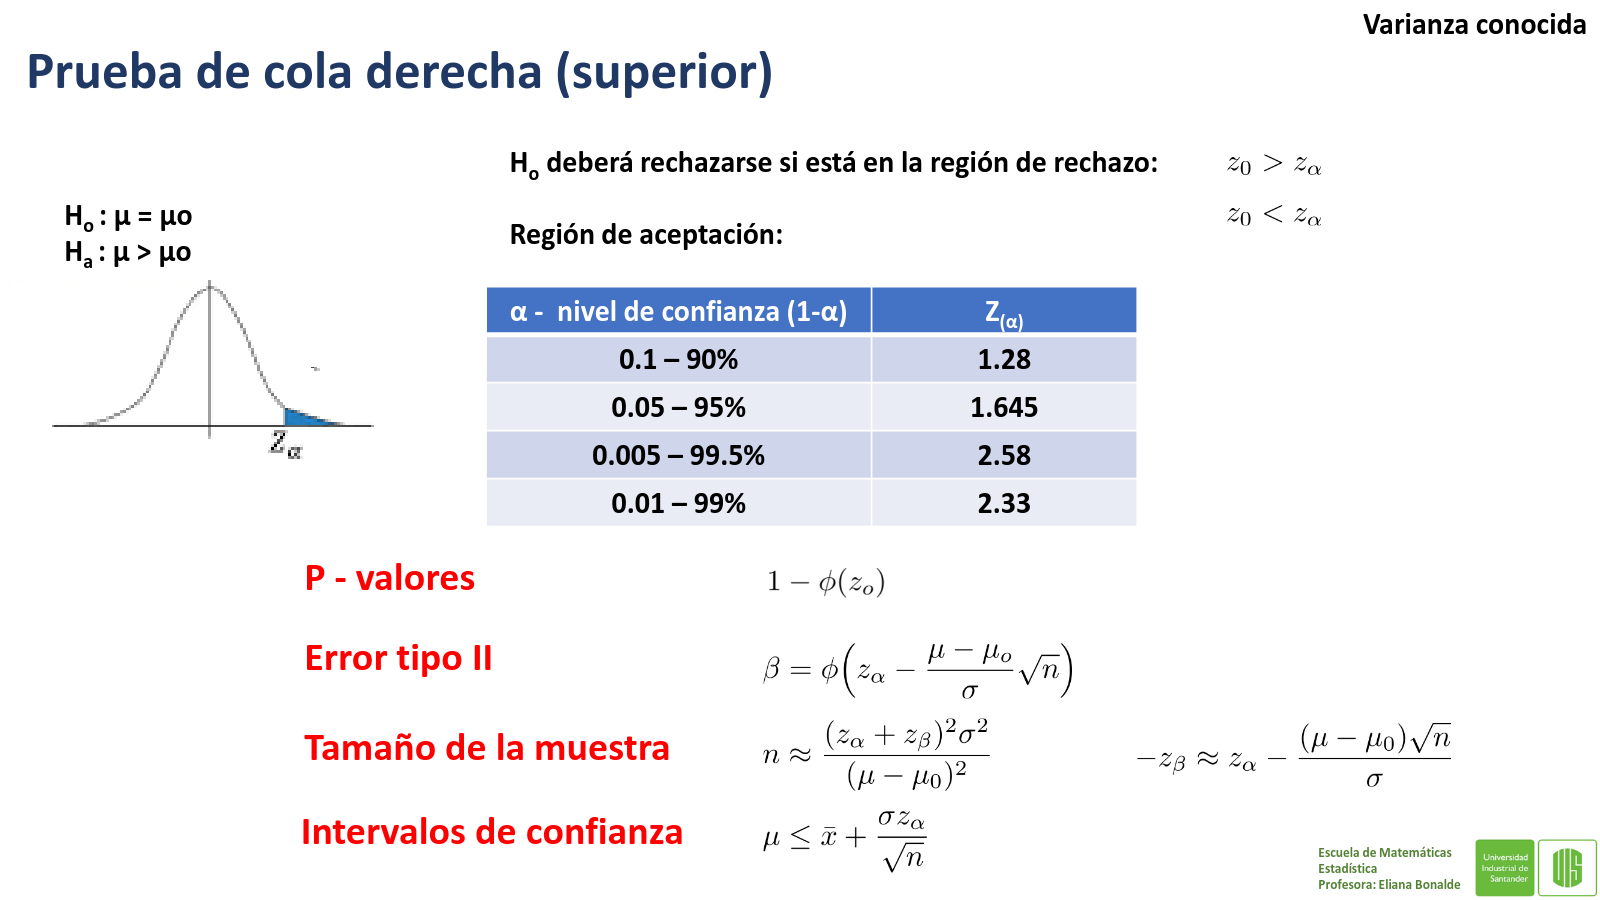 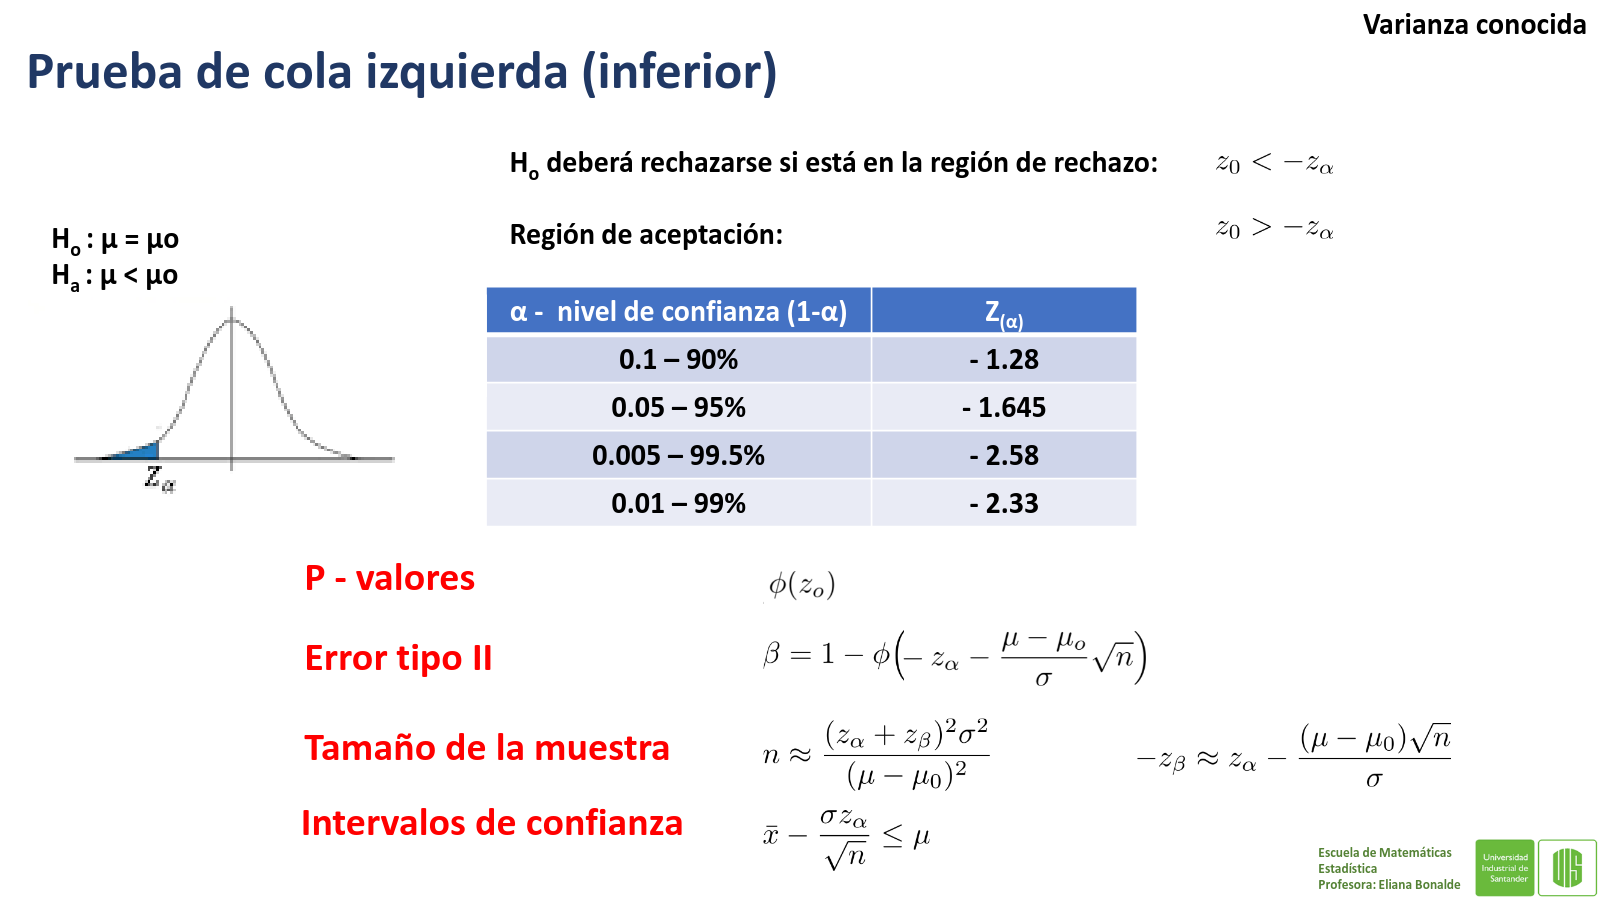

## Calculo de intervalos de confiaza y el valor critico

In [ ]:
def nivel_de_confianza(z):
    confianza = (stat.norm.cdf(z) - stat.norm.cdf(-z)) * 100
    print(f"Para z = {z}, el nivel de confianza es: {confianza:.2f}%")

# Para los incisos (c) y (d) -> Te dan Confianza, buscas Z
def valor_critico_z(confianza_pct):
    alfa = 1 - (confianza_pct / 100)
    z = stat.norm.ppf(1 - alfa/2)
    print(f"Para {confianza_pct}% de confianza, z = {z:.3f}")
    return z
    
def analizar_intervalos_comparativos(int1, int2):
    # a. Hallar la media muestral (Punto medio)
    # Como ambos vienen de la misma muestra, el centro es el mismo
    x_barra_1 = (int1[0] + int1[1]) / 2
    x_barra_2 = (int2[0] + int2[1]) / 2
    
    # b. Calcular amplitudes para determinar confianza
    amp1 = int1[1] - int1[0]
    amp2 = int2[1] - int2[0]
    
    print(f"--- Análisis de Resultados ---")
    print(f"Media muestral (x_barra): {x_barra_1} Hz")
    print(f"Amplitud Intervalo 1: {amp1:.2f}")
    print(f"Amplitud Intervalo 2: {amp2:.2f}")
    
    print(f"\n--- Conclusión para el inciso b ---")
    if amp1 < amp2:
        print(f"El intervalo {int1} es más estrecho, por lo tanto es el del 90% de confianza.")
        print(f"El intervalo {int2} es más ancho, por lo tanto es el del 99% de confianza.")
    else:
        print(f"El intervalo {int2} es más estrecho, por lo tanto es el del 90% de confianza.")
        print(f"El intervalo {int1} es más ancho, por lo tanto es el del 99% de confianza.")

def calcular_intervalo_confianza(x_barra, sigma, n, z_critico):
    """
    Calcula los límites de un intervalo de confianza.
    
    Argumentos:
    x_barra: Media muestral
    sigma: Desviación estándar (poblacional o muestral según el caso)
    n: Tamaño de la muestra
    z_critico: El valor crítico ya calculado (Z o t)
    """
    # 1. Calcular el Error Estándar (SE)
    error_estandar = sigma / np.sqrt(n)
    
    # 2. Calcular el Margen de Error (E)
    margen_error = z_critico * error_estandar
    
    # 3. Determinar límites
    inferior = x_barra - margen_error
    superior = x_barra + margen_error
    
    print(f"--- Resultado del Intervalo ---")
    print(f"Margen de Error (E): {margen_error:.4f}")
    print(f"Intervalo: ({inferior:.4f}, {superior:.4f})")
    
    return inferior, superior
    

## Prueba de hipotesis z

In [ ]:
def prueba_hipotesis_completa(x_barra, mu_0, sigma, n, alpha, cola, x_sup=None):
    
    z = (x_barra - mu_0) / (sigma / np.sqrt(n))
    x = np.linspace(-5, 5, 1000)
    y_H0 = stat.norm.pdf(x, 0, 1)
    
    plt.figure(figsize=(10,6))
    plt.plot(x, y_H0, label='Distribución bajo H0')

    # Solo grafica H1 y calcula delta si se proporcionó x_sup
    if x_sup is not None:
        delta = abs(x_sup - mu_0) / (sigma / np.sqrt(n))
        y_H1  = stat.norm.pdf(x, delta, 1)
        plt.plot(x, y_H1, linestyle='--', label='Distribución bajo H1')
    
    match cola:
        case 'inf':
            z_alpha   = stat.norm.ppf(1 - alpha)
            z_crit    = -z_alpha
            decision  = z < z_crit
            p_value   = stat.norm.cdf(z)
            limite_sup = x_barra + z_alpha * (sigma / np.sqrt(n))
            IC        = (-np.inf, limite_sup)
            
            # Beta solo si se conoce x_sup
            beta = stat.norm.cdf(z_alpha + delta) if x_sup is not None else None
            
            plt.fill_between(x, y_H0, where=(x < z_crit), alpha=0.3)
            if x_sup is not None:
                plt.fill_between(x, y_H1, where=(x >= z_crit), alpha=0.3)

        case 'sup':
            z_alpha   = stat.norm.ppf(1 - alpha)
            z_crit    = +z_alpha
            decision  = z > z_crit
            p_value   = 1 - stat.norm.cdf(z)
            limite_inf = x_barra - z_alpha * (sigma / np.sqrt(n))
            IC        = (limite_inf, np.inf)
            
            beta = stat.norm.cdf(z_alpha - delta) if x_sup is not None else None
            
            plt.fill_between(x, y_H0, where=(x > z_crit), alpha=0.3)
            if x_sup is not None:
                plt.fill_between(x, y_H1, where=(x <= z_crit), alpha=0.3)

        case 'dos':
            z_alpha   = stat.norm.ppf(1 - alpha/2)
            z_crit    = z_alpha
            decision  = abs(z) > z_crit
            p_value   = 2 * (1 - stat.norm.cdf(abs(z)))
            limite_inf = x_barra - z_alpha * (sigma / np.sqrt(n))
            limite_sup = x_barra + z_alpha * (sigma / np.sqrt(n))
            IC        = (limite_inf, limite_sup)
            
            beta = (stat.norm.cdf(z_alpha - delta) - 
                    stat.norm.cdf(-z_alpha - delta)) if x_sup is not None else None
            
            plt.fill_between(x, y_H0, where=(x > z_crit),  alpha=0.3)
            plt.fill_between(x, y_H0, where=(x < -z_crit), alpha=0.3)
            if x_sup is not None:
                plt.fill_between(x, y_H1, where=(abs(x) <= z_crit), alpha=0.3)

        case _:
            raise ValueError("cola no válida")

    plt.axvline(z, linestyle=':', label='Z observado')
    plt.title("Prueba de hipótesis completa")
    plt.legend()
    plt.grid()
    plt.show()

    return {
        'z': z,
        'decision': decision,
        'p_value': p_value,
        'beta': beta,   # None si no se pasó x_sup
        'IC': IC
    }


#posible uso:
# Sin x_sup → beta retorna None, no falla
#prueba_hipotesis_completa(94, 100, 15, 25, 0.05, 'inf')

# Con x_sup → calcula beta normalmente
#prueba_hipotesis_completa(94, 100, 15, 25, 0.05, 'inf', x_sup=90)



## Prueba de hiptesis t  (desv poblacional desconocida)

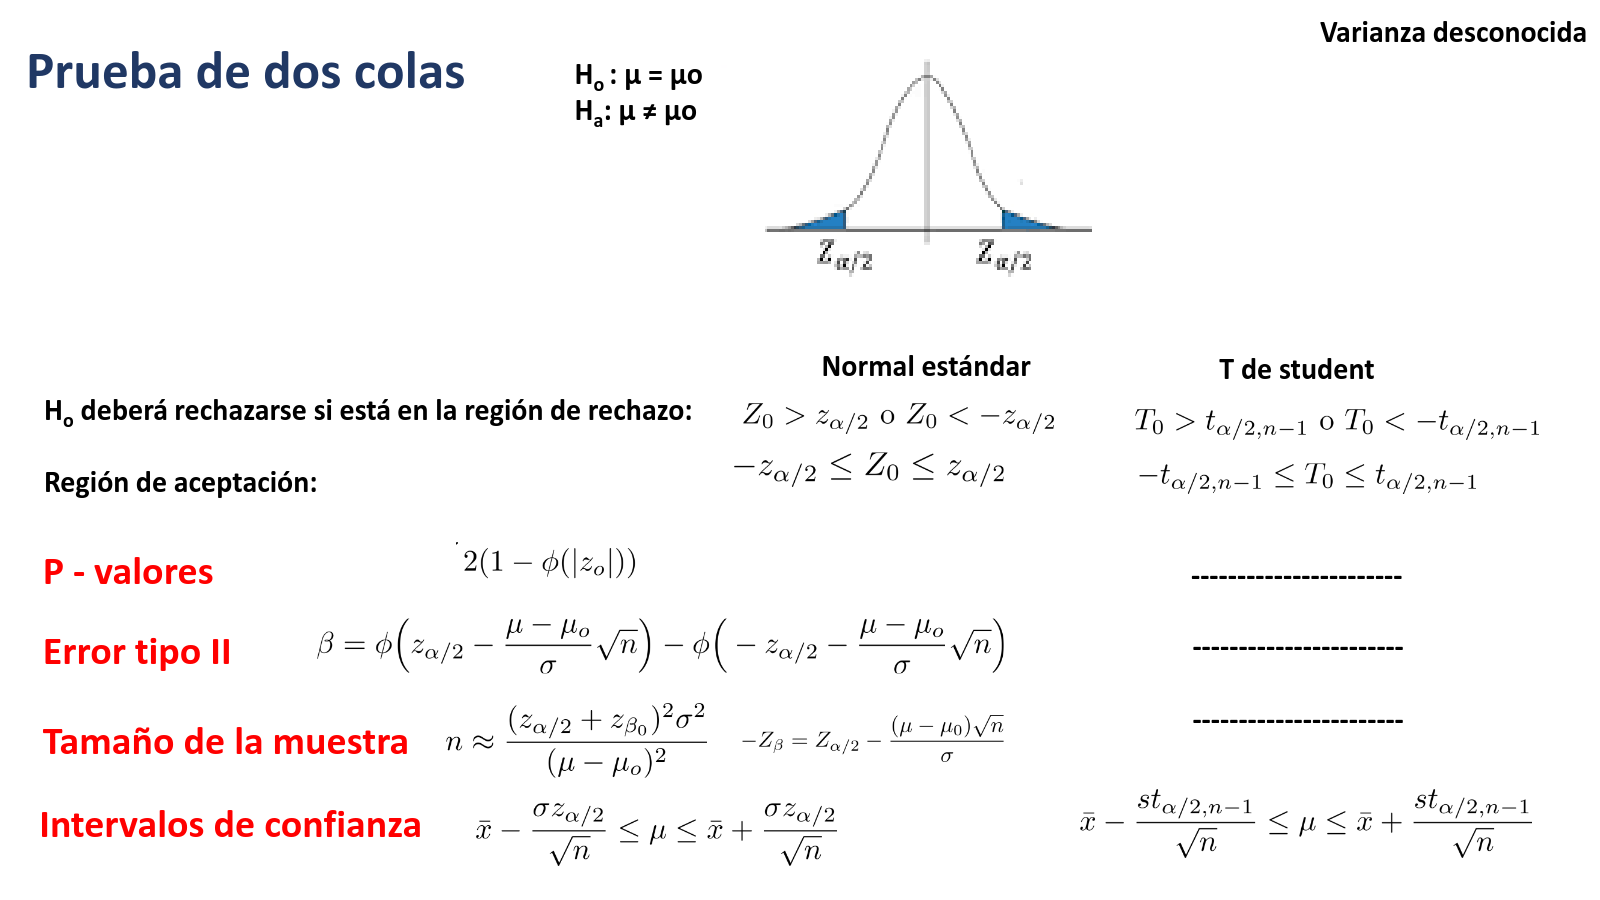 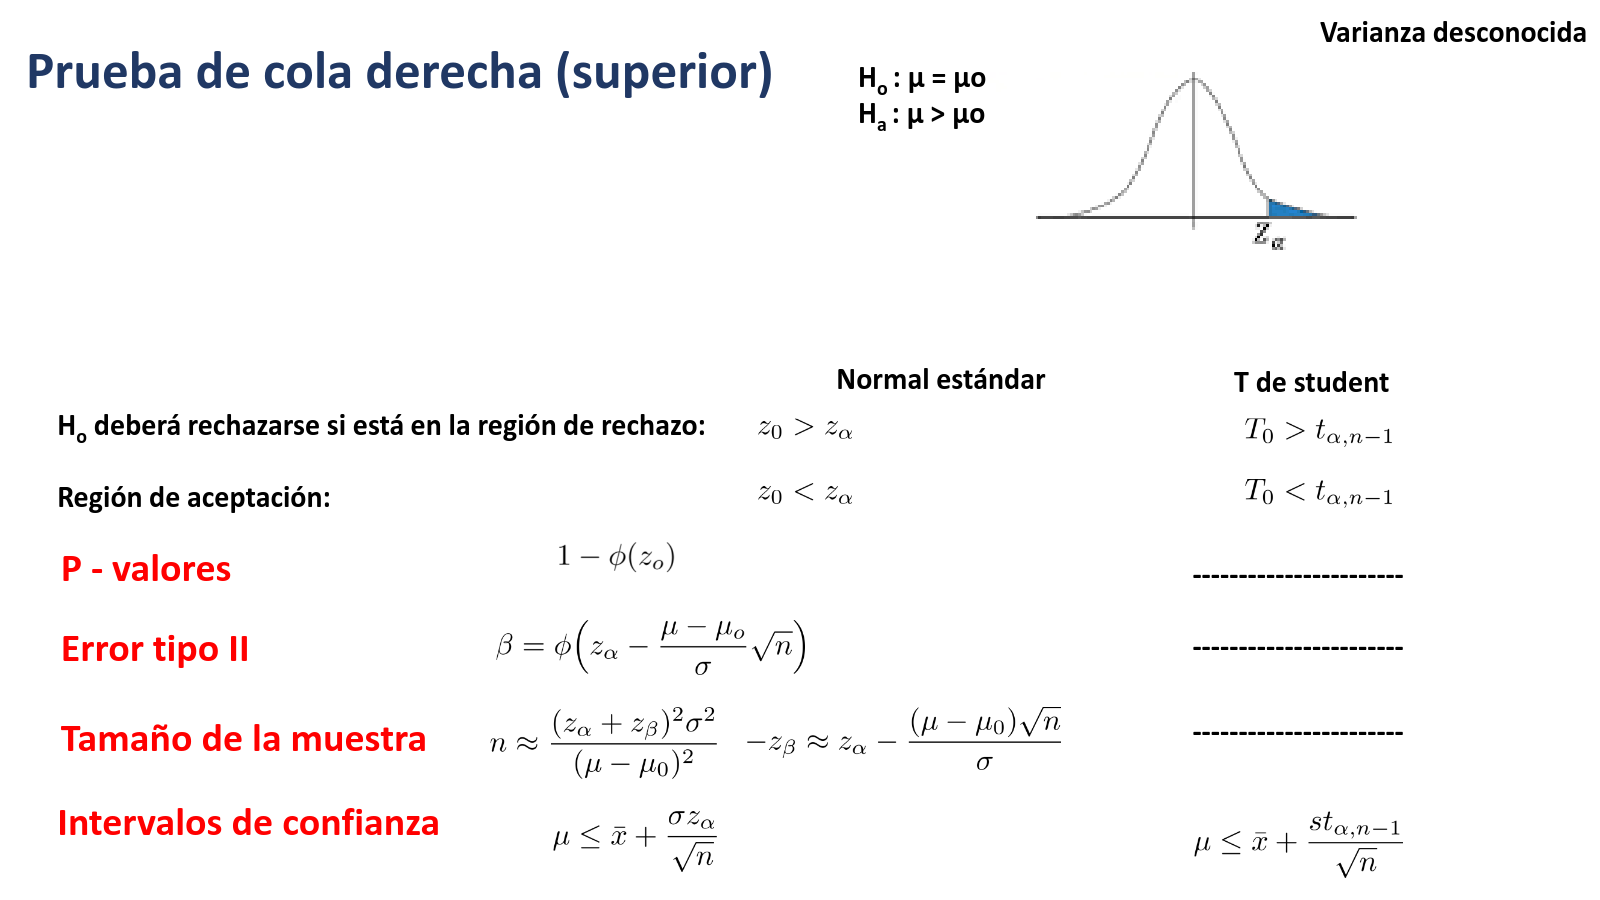 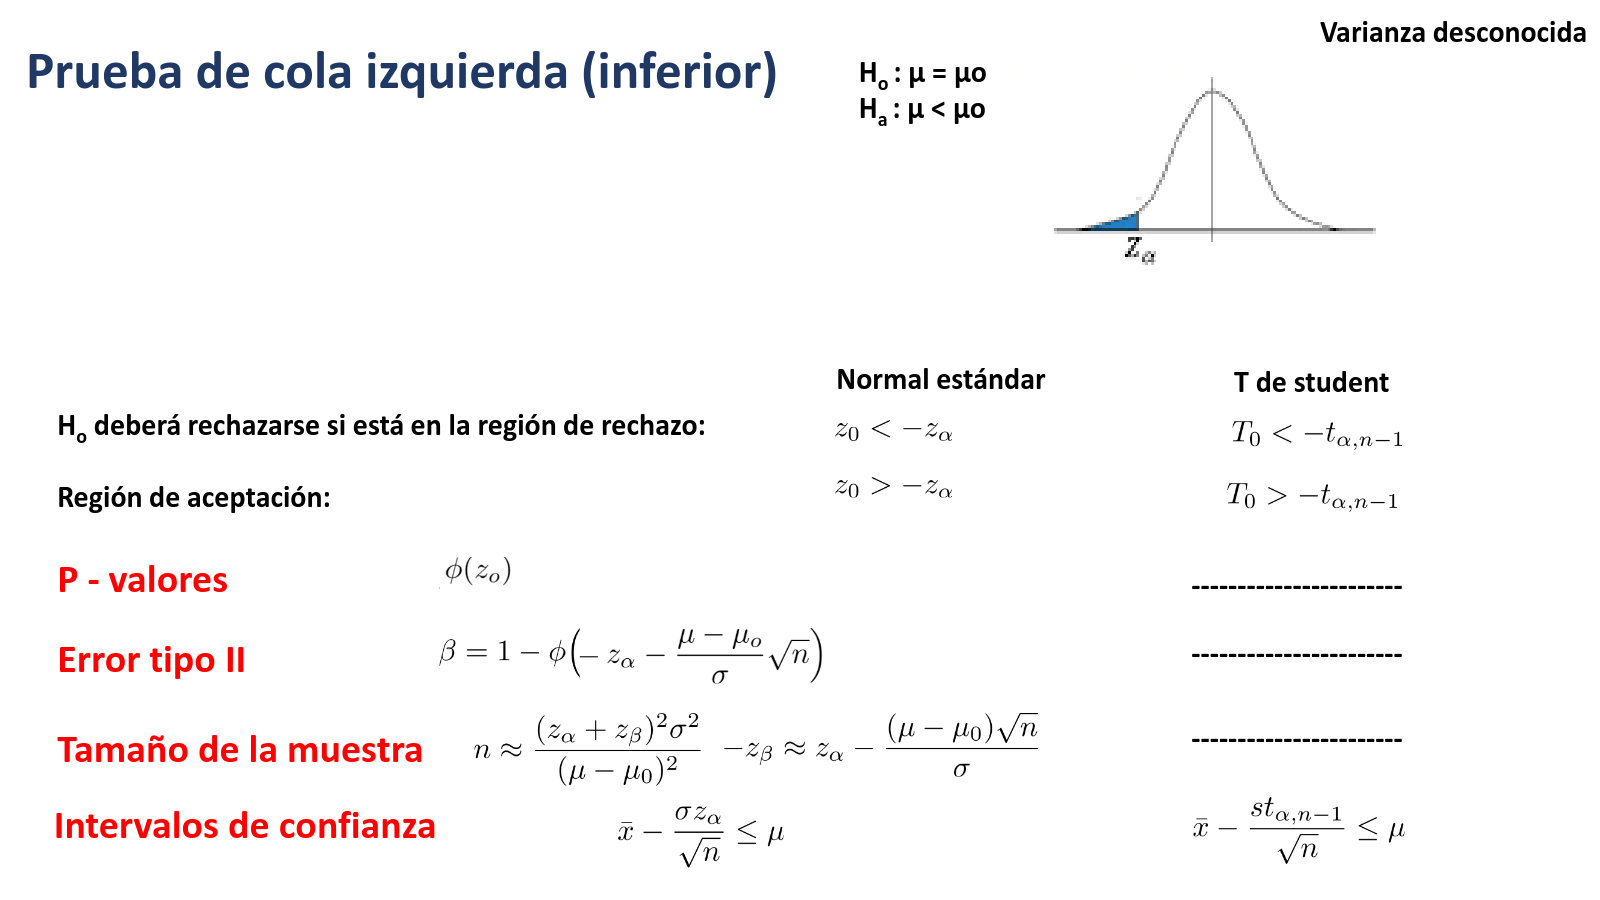  

In [ ]:


def prueba_t_media(x_barra, mu_0, s, n, alpha, cola, x_sup=None):
    
    gl = n - 1  # grados de libertad
    t  = (x_barra - mu_0) / (s / np.sqrt(n))
    
    x    = np.linspace(-5, 5, 1000)
    y_H0 = stats.t.pdf(x, df=gl)   
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x, y_H0, 'b-', linewidth=2, label='Distribución bajo H₀')

    if x_sup is not None:
        delta = abs(x_sup - mu_0) / (s / np.sqrt(n))
        y_H1  = stats.t.pdf(x - delta, df=gl)
        ax.plot(x, y_H1, 'g--', linewidth=2, label='Distribución bajo H₁')

    match cola:
        case 'inf':
            t_alpha   = stats.t.ppf(1 - alpha, df=gl)
            t_crit    = -t_alpha
            decision  = t < t_crit
            p_value   = stats.t.cdf(t, df=gl)
            limite_sup = x_barra + t_alpha * (s / np.sqrt(n))
            IC        = (-np.inf, limite_sup)
            decision_ic = mu_0 > IC[1]
            beta      = stats.t.cdf(t_alpha + delta, df=gl) if x_sup is not None else None

            # Zona de rechazo izquierda
            ax.fill_between(x, y_H0, where=(x < t_crit), alpha=0.4, color='red', label='Zona de rechazo')
            # Zona de no rechazo
            ax.fill_between(x, y_H0, where=(x >= t_crit), alpha=0.15, color='green', label='Zona de no rechazo')
            if x_sup is not None:
                ax.fill_between(x, y_H1, where=(x >= t_crit), alpha=0.3, color='orange', label='β (error tipo II)')

        case 'sup':
            t_alpha   = stats.t.ppf(1 - alpha, df=gl)
            t_crit    = +t_alpha
            decision  = t > t_crit
            p_value   = 1 - stats.t.cdf(t, df=gl)
            limite_inf = x_barra - t_alpha * (s / np.sqrt(n))
            IC        = (limite_inf, np.inf)
            decision_ic = mu_0 < IC[0] 
            beta      = stats.t.cdf(t_alpha - delta, df=gl) if x_sup is not None else None

            # Zona de rechazo derecha
            ax.fill_between(x, y_H0, where=(x > t_crit), alpha=0.4, color='red', label='Zona de rechazo')
            # Zona de no rechazo
            ax.fill_between(x, y_H0, where=(x <= t_crit), alpha=0.15, color='green', label='Zona de no rechazo')
            if x_sup is not None:
                ax.fill_between(x, y_H1, where=(x <= t_crit), alpha=0.3, color='orange', label='β (error tipo II)')

        case 'dos':
            t_alpha   = stats.t.ppf(1 - alpha/2, df=gl)
            t_crit    = t_alpha
            decision  = abs(t) > t_crit
            p_value   = 2 * (1 - stats.t.cdf(abs(t), df=gl))
            limite_inf = x_barra - t_alpha * (s / np.sqrt(n))
            limite_sup = x_barra + t_alpha * (s / np.sqrt(n))
            IC        = (limite_inf, limite_sup)
            decision_ic = not (IC[0] <= mu_0 <= IC[1])
            beta      = (stats.t.cdf(t_alpha - delta, df=gl) - stats.t.cdf(-t_alpha - delta, df=gl)) if x_sup is not None else None

            # Zonas de rechazo ambas colas
            ax.fill_between(x, y_H0, where=(x >  t_crit), alpha=0.4, color='red', label='Zona de rechazo')
            ax.fill_between(x, y_H0, where=(x < -t_crit), alpha=0.4, color='red')
            # Zona de no rechazo centro
            ax.fill_between(x, y_H0, where=((x >= -t_crit) & (x <= t_crit)), alpha=0.15, color='green', label='Zona de no rechazo')
            if x_sup is not None:
                ax.fill_between(x, y_H1, where=(abs(x) <= t_crit), alpha=0.3, color='orange', label='β (error tipo II)')

        case _:
            raise ValueError("cola no válida")

    # Centro de la distribución
    ax.axvline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.5, label='Centro (μ₀)')

    # t crítico/s
    if cola == 'dos':
        ax.axvline( t_crit, color='orange', linestyle='--', linewidth=2, label=f't crítico = ±{t_crit:.4f}')
        ax.axvline(-t_crit, color='orange', linestyle='--', linewidth=2)
        ax.text( t_crit, ax.get_ylim()[1]*0.85, f'+{t_crit:.3f}', ha='center', fontsize=9, color='darkorange', fontweight='bold')
        ax.text(-t_crit, ax.get_ylim()[1]*0.85, f'-{t_crit:.3f}', ha='center', fontsize=9, color='darkorange', fontweight='bold')
    else:
        ax.axvline(t_crit, color='orange', linestyle='--', linewidth=2, label=f't crítico = {t_crit:.4f}')
        ax.text(t_crit, max(y_H0)*0.85, f'{t_crit:.3f}', ha='center', fontsize=9, color='darkorange', fontweight='bold')

    # t observado
    color_t = 'red' if decision else 'purple'
    ax.axvline(t, color=color_t, linestyle=':', linewidth=2.5, label=f't observado = {t:.4f}')
    ax.text(t, max(y_H0)*0.70, f'{t:.3f}', ha='center', fontsize=9, color=color_t, fontweight='bold')

    ax.set_title(f'Prueba t para la media (σ desconocida) — Cola: {cola}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valores t', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    sep = "=" * 40
    print(f"\n{sep}")
    print(f"  RESULTADO PRUEBA T")
    print(sep)
    print(f"  H0: μ = {mu_0}")
    print(f"  t crítico  : {t_crit:.4f}")
    print(f"  t observado: {t:.4f}")
    print(f"  p-valor    : {p_value:.4f}")
    print(f"  α          : {alpha}")
    print(f"  IC         : {IC}")
    if beta is not None:
        print(f"  β (error II): {beta:.4f}")
    print(sep)

    # 3 criterios de decisión
    print(f"  Por t:   {'RECHAZAR H0' if decision    else 'NO RECHAZAR H0'}")
    print(f"  Por p:   {'RECHAZAR H0' if p_value < alpha else 'NO RECHAZAR H0'}  (p {'<' if p_value < alpha else '>='} α)")
    print(f"  Por IC:  {'RECHAZAR H0' if decision_ic else 'NO RECHAZAR H0'}  (μ0 {'fuera' if decision_ic else 'dentro'} del IC)")
    print(sep)

    return {
        't': t,
        't_critic': t_crit,
        'gl': gl,
        'decision': decision,
        'p_value': p_value,
        'beta': beta,
        'IC': IC
    }


#posible uso:
# Sin x_sup → beta retorna None, no falla
#prueba_t_media(94, 100, 15, 25, 0.05, 'inf')
# Con x_sup → calcula beta normalmente
#prueba_t_media(94, 100, 15, 25, 0.05, 'inf', x_sup=90)


## Función para hipotesis de dos muestras

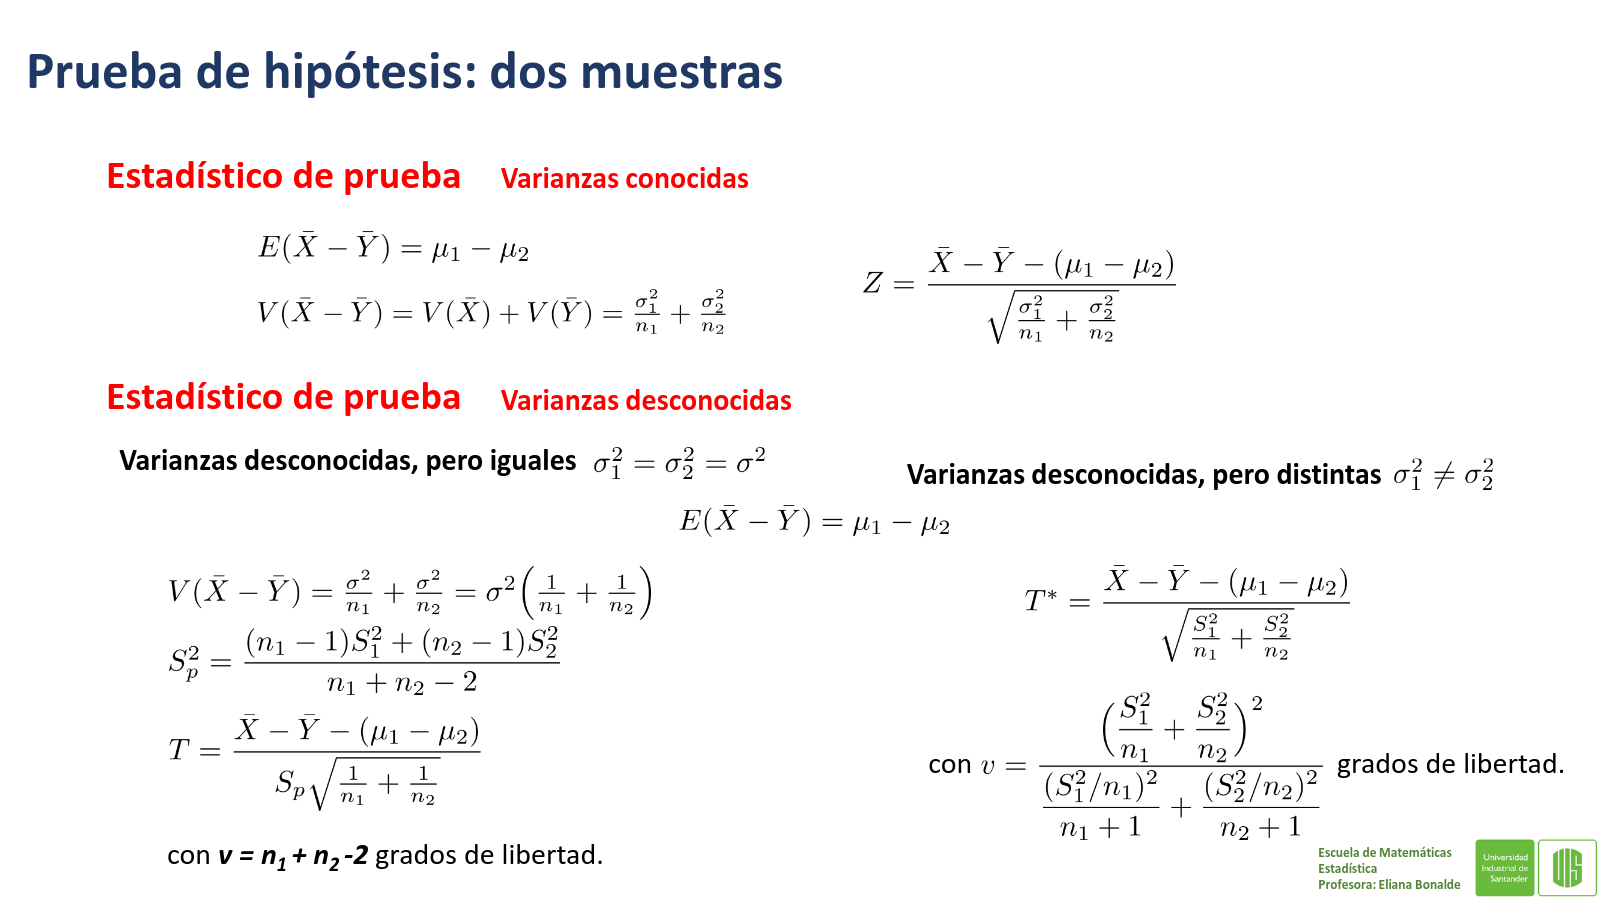 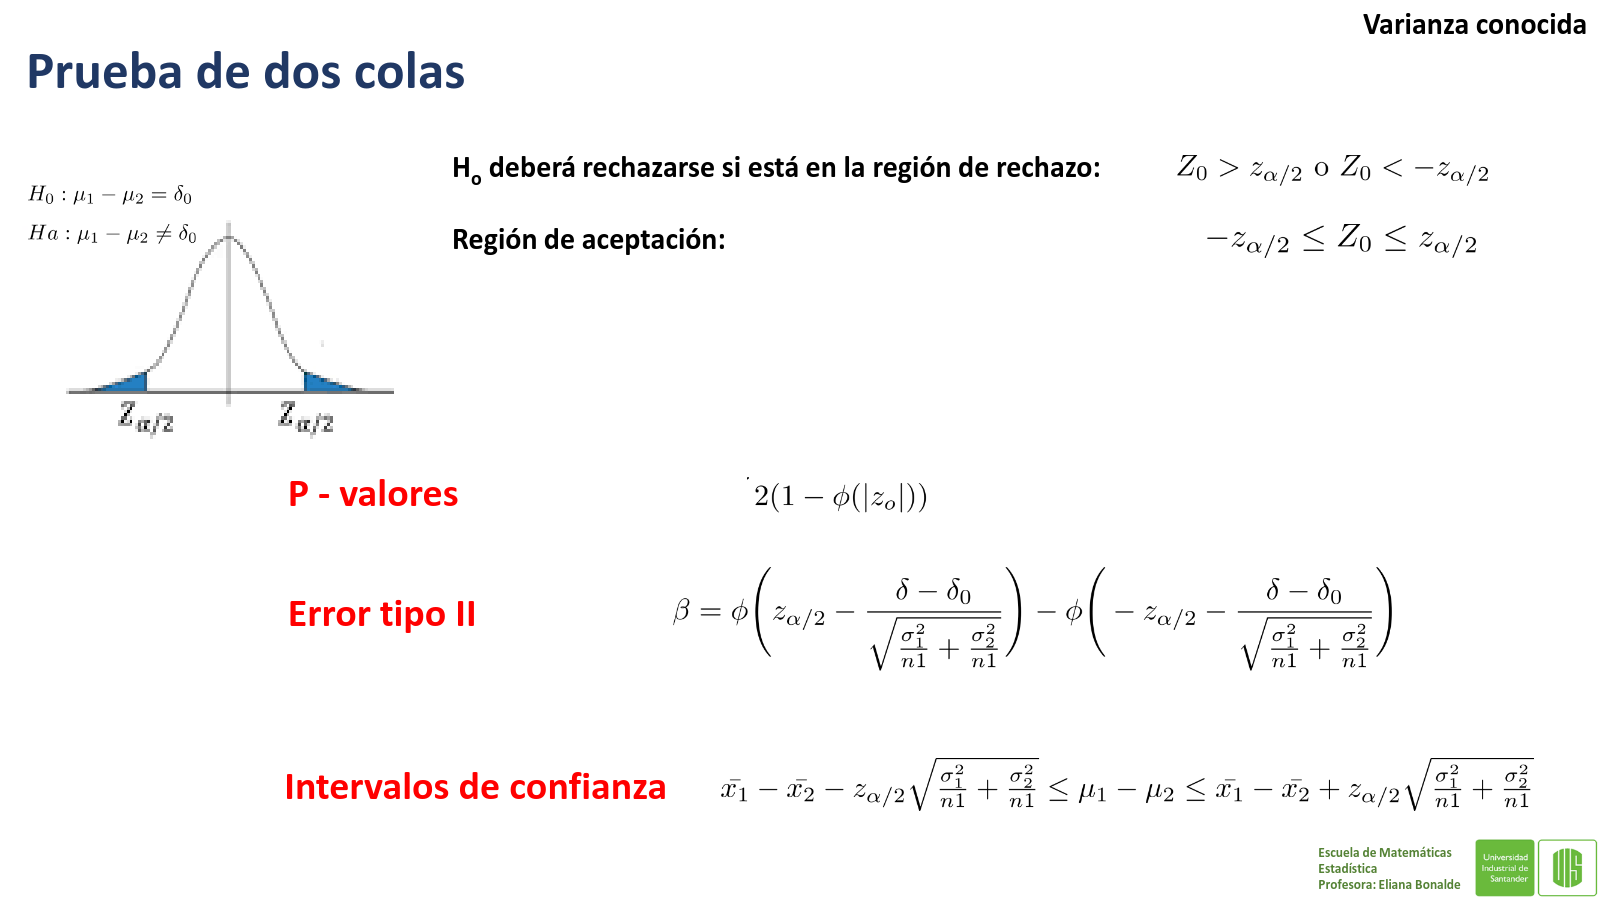 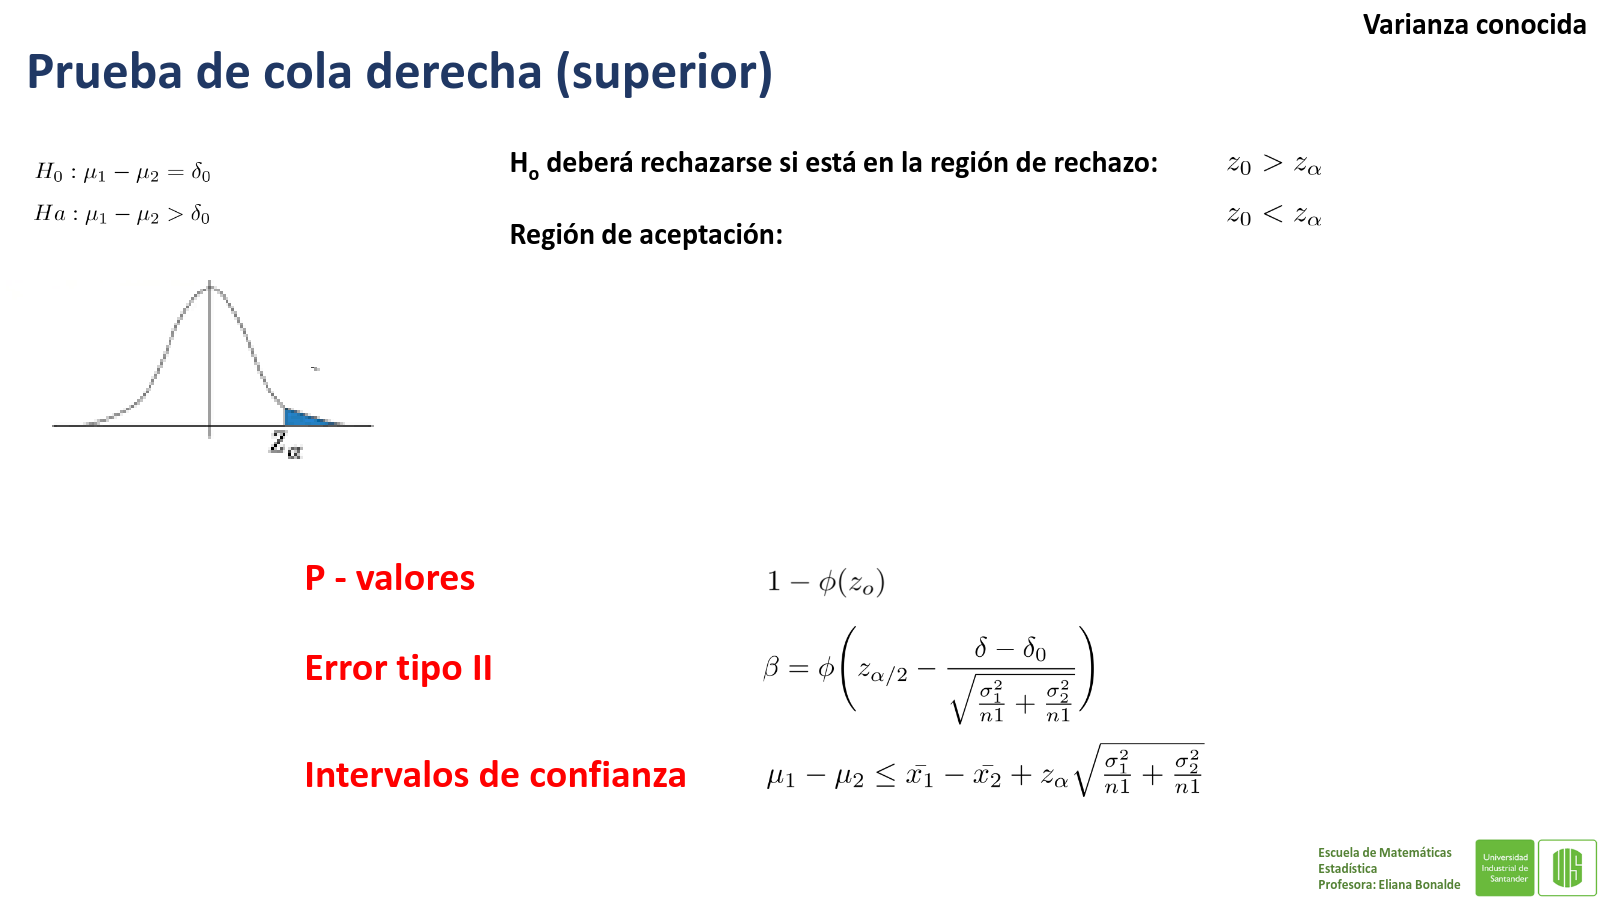 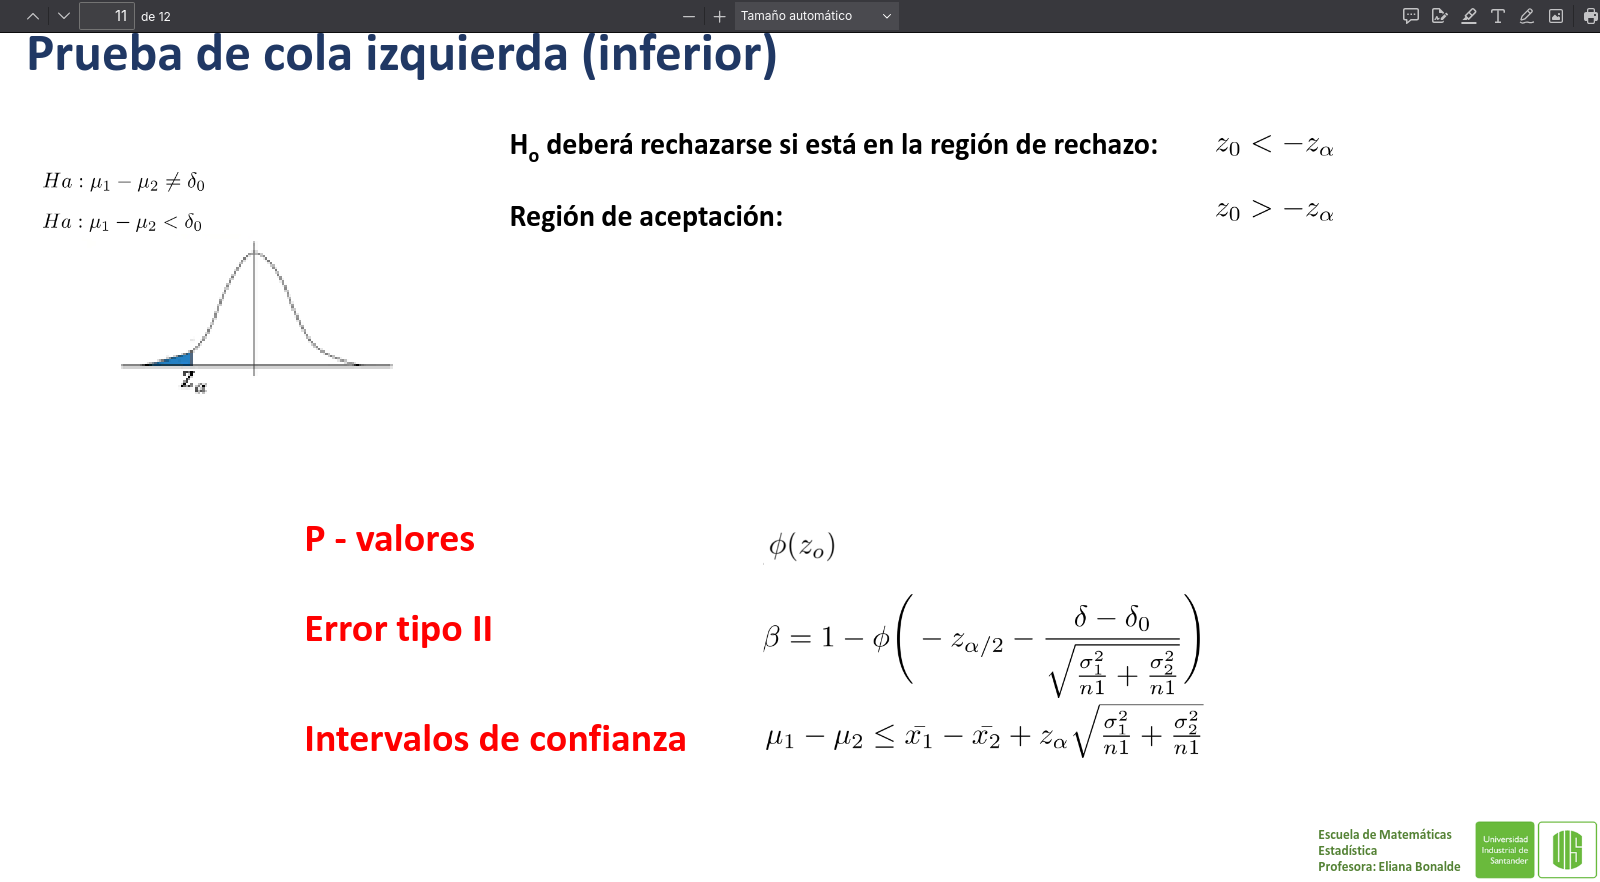

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def prueba_t_dos_muestras(n1,n2,m1, m2,v1,v2, alpha=0.05, titulo="Prueba t de Welch"):
    """
    Realiza una prueba t para dos muestras independientes (varianzas no necesariamente iguales).
    """
    
    diff_medias = m1 - m2
    
    # 2. Estadístico t y Grados de libertad (Welch-Satterthwaite)
    # t = (m1 - m2) / sqrt(v1/n1 + v2/n2)
    error_estandar_comb = np.sqrt((v1/n1) + (v2/n2))
    t_obs = diff_medias / error_estandar_comb
    
    numerador_gl = (v1/n1 + v2/n2)**2
    denominador_gl = ((v1/n1)**2 / (n1-1)) + ((v2/n2)**2 / (n2-1))
    gl = numerador_gl / denominador_gl
    
    # 3. Valores críticos e IC (Bilateral)
    t_critico = stats.t.ppf(1 - alpha/2, df=gl)
    p_valor = 2 * (1 - stats.t.cdf(abs(t_obs), df=gl))
    
    margen = t_critico * error_estandar_comb
    IC = (diff_medias - margen, diff_medias + margen)
    
    # 4. Impresión de resultados
    sep = "=" * 50
    print(f"\n{sep}")
    print(f"  {titulo.upper()}")
    print(sep)
    print(f"  Diferencia de medias : {diff_medias:.4f}")
    print(f"  t observado          : {t_obs:.4f}")
    print(f"  t crítico (±)        : ±{t_critico:.4f}")
    print(f"  Grados de libertad   : {gl:.2f}")
    print(f"  p-valor              : {p_valor:.6f}")
    print(f"  IC {int((1-alpha)*100)}% diferencia   : [{IC[0]:.4f}, {IC[1]:.4f}]")
    print("-" * 50)
    
    if p_valor < alpha:
        print("  RESULTADO: SE RECHAZA H0 (Hay diferencia significativa)")
    else:
        print("  RESULTADO: NO SE RECHAZA H0 (No hay diferencia significativa)")
    print(f"{sep}\n")

    # 5. Gráfica de la distribución t
    x = np.linspace(-5, 5, 1000)
    y_t = stats.t.pdf(x, df=gl)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y_t, 'b-', lw=2, label=f'Distribución t (gl={gl:.1f})')
    
    # Zonas de rechazo
    ax.fill_between(x, y_t, where=(x > t_critico), color='red', alpha=0.4, label='Zona de rechazo')
    ax.fill_between(x, y_t, where=(x < -t_critico), color='red', alpha=0.4)
    # Zona de no rechazo
    ax.fill_between(x, y_t, where=((x >= -t_critico) & (x <= t_critico)), 
                    color='green', alpha=0.15, label='Zona de no rechazo')
    
    # Líneas de referencia
    ax.axvline(t_obs, color='purple', ls=':', lw=2.5, label=f't observado = {t_obs:.3f}')
    ax.axvline(t_critico, color='orange', ls='--', lw=2, label=f't crítico = ±{t_critico:.3f}')
    ax.axvline(-t_critico, color='orange', ls='--', lw=2)
    
    ax.set_title(f'{titulo}\n(Bilateral)', fontweight='bold')
    ax.set_xlabel('Valores t')
    ax.set_ylabel('Densidad')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return {"t": t_obs, "p_valor": p_valor, "IC": IC, "gl": gl}

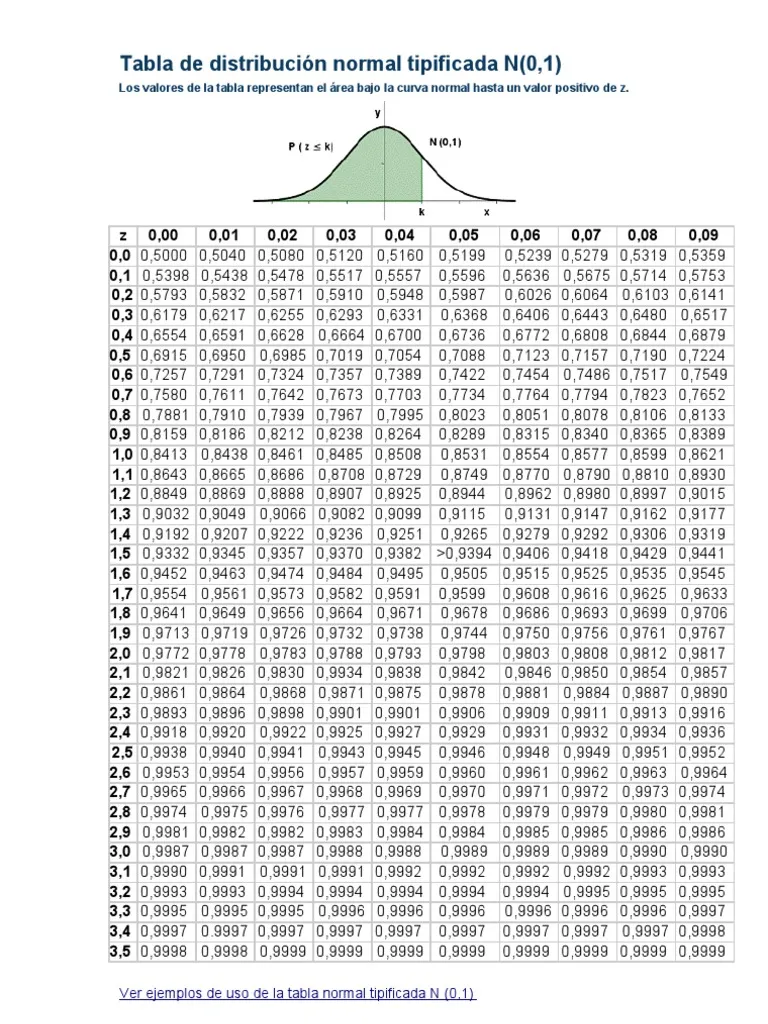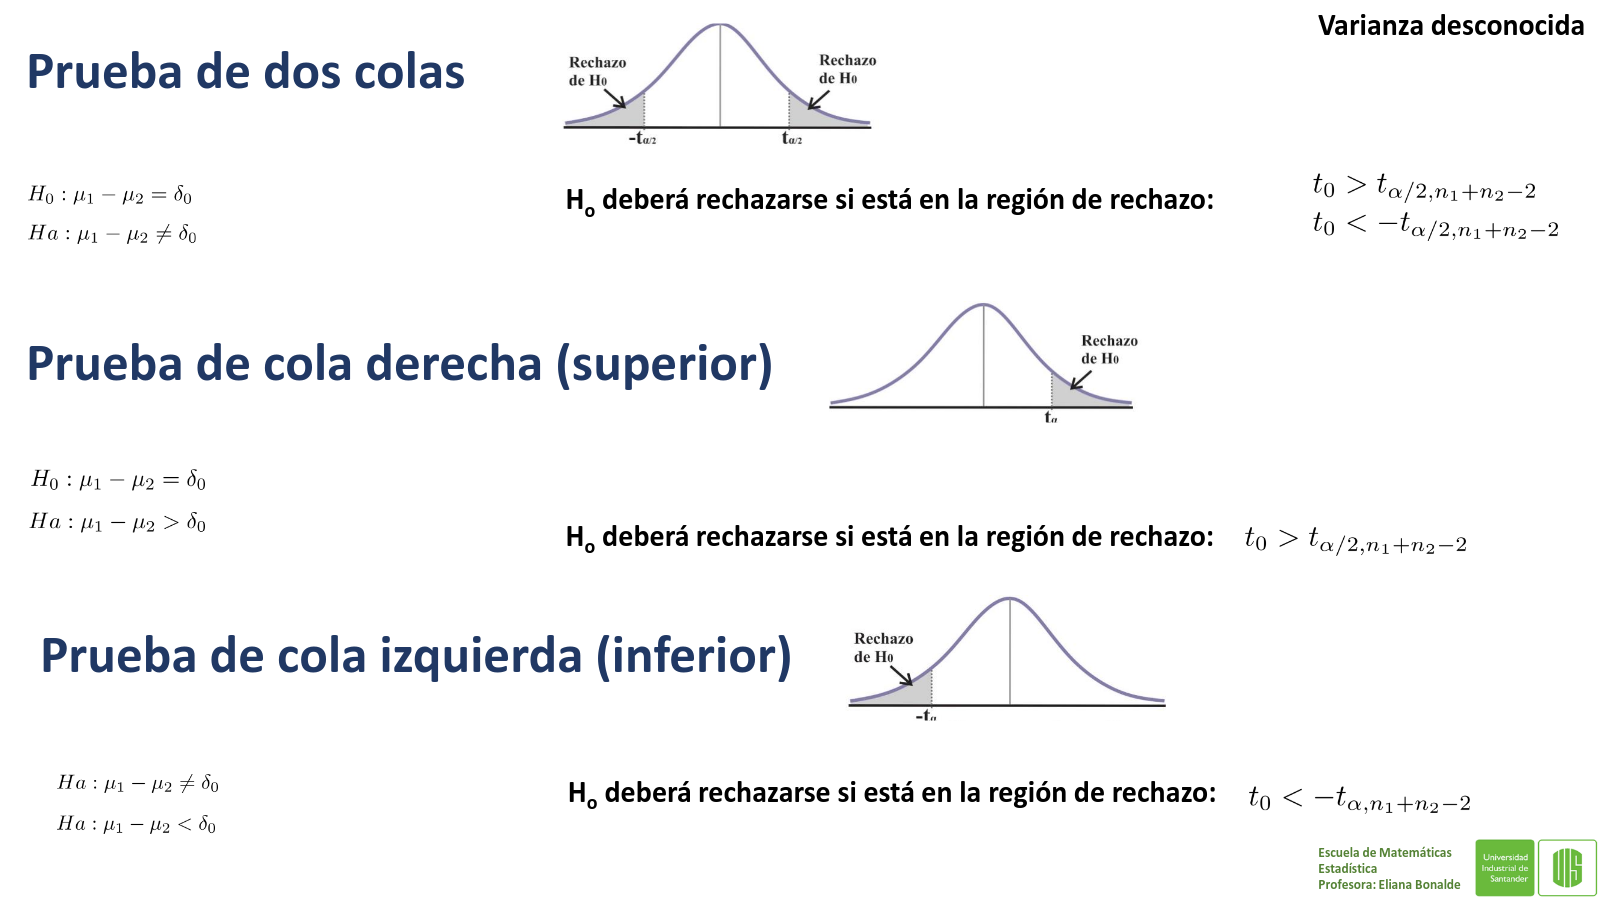 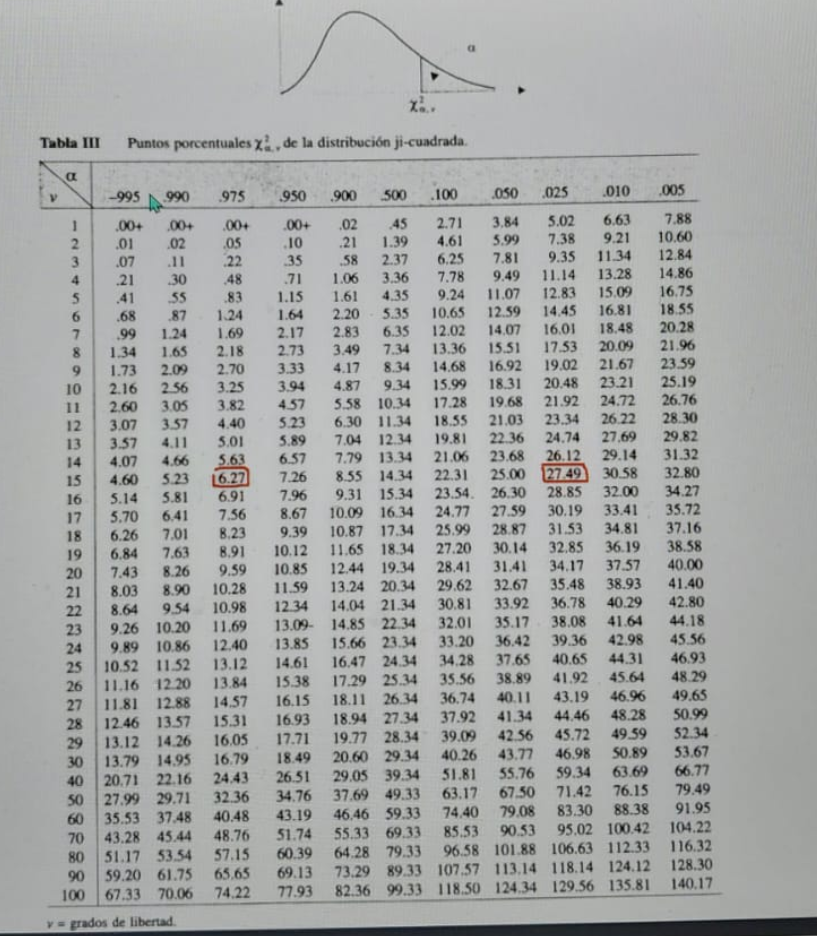

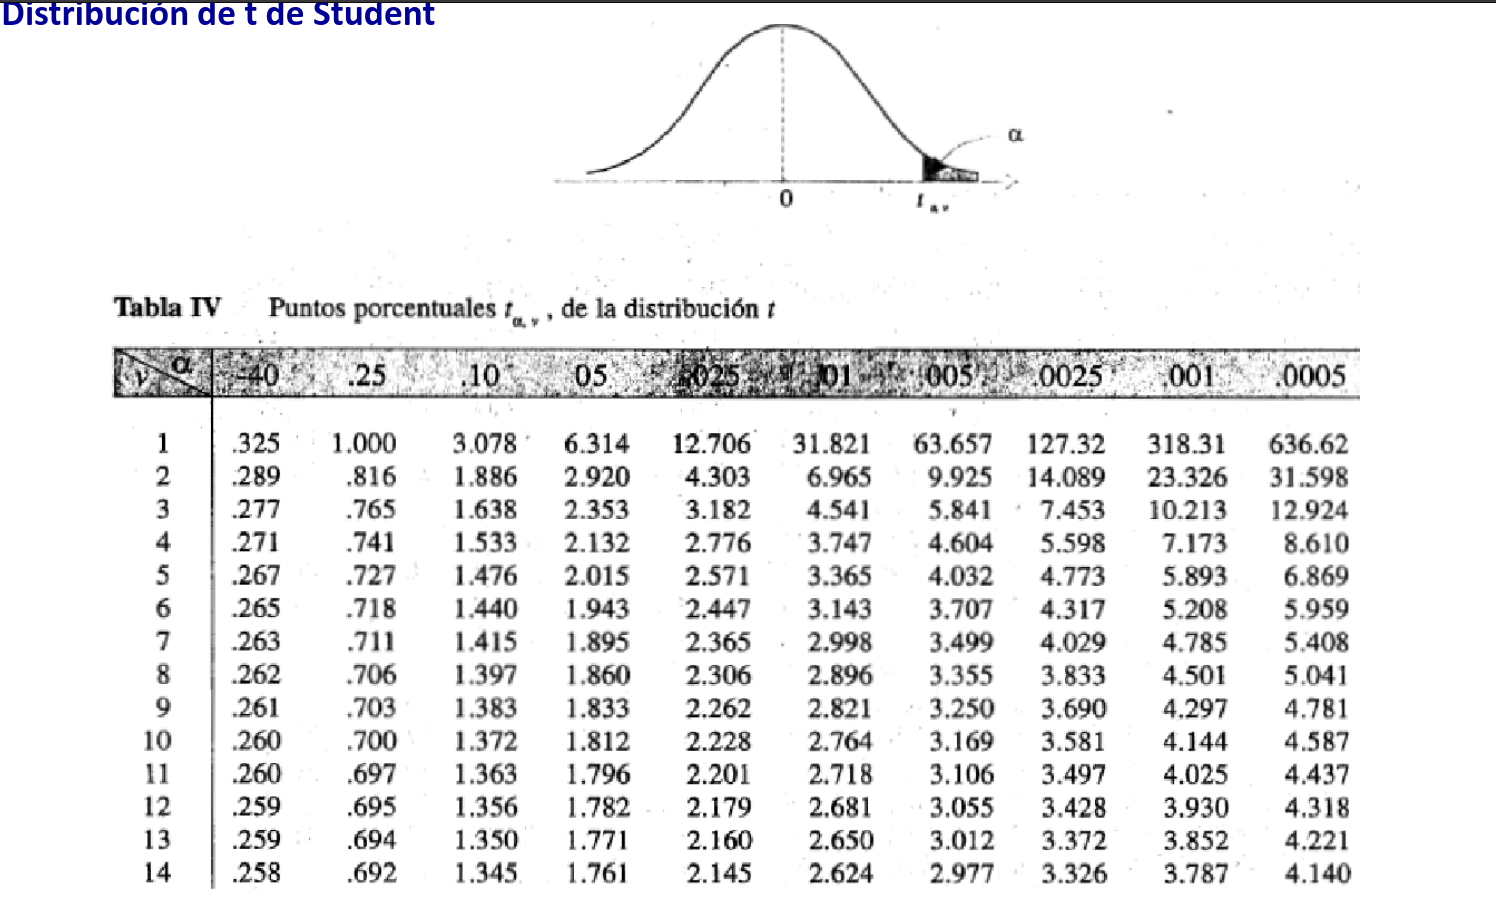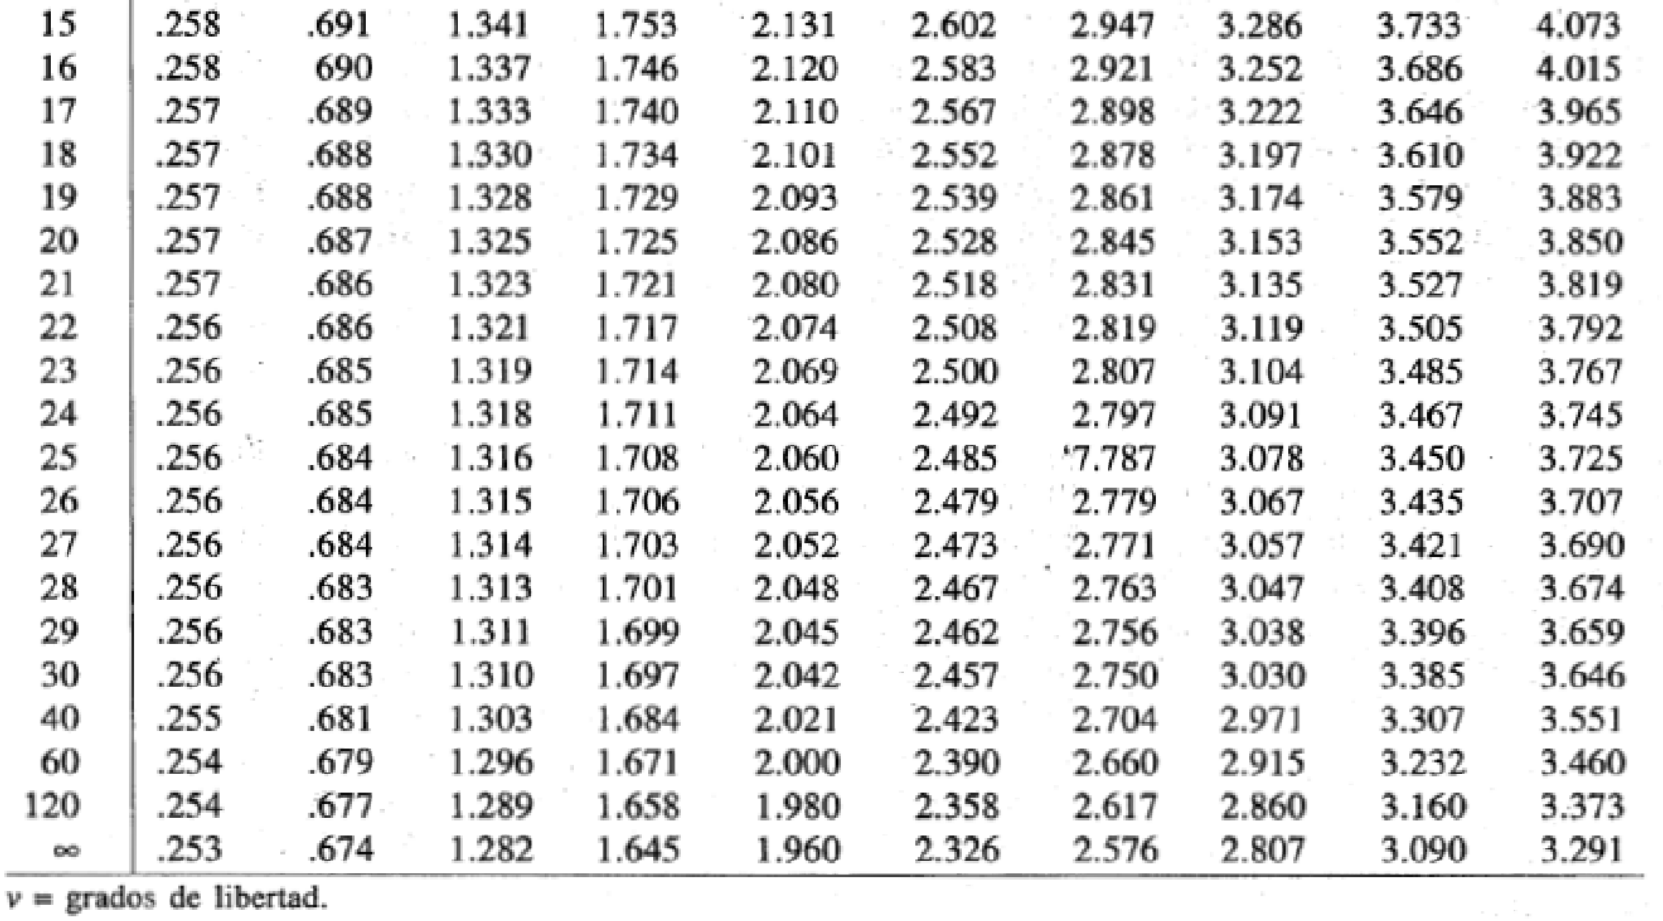